# Xarxes Recurrents (RNN)

## Limitacions del MLP amb dades seqüencials

Els MLP que hem vist al bloc 2 tracten cada mostra de manera independent: no tenen memòria dels inputs anteriors. Això és adequat quan les mostres no tenen relació entre elles, però en una sèrie temporal l'ordre i el context temporal són essencials per fer una bona predicció.

Com ja hem comentat abans la finestra té una mida fixa i el model no pot aprendre dependències més llargues que la finestra definida. A més, tracta tots els valors de la finestra de manera simètrica, sense tenir en compte que els valors més recents solen ser més rellevants.

## Arquitectura RNN

Una xarxa recurrent (RNN) soluciona aquest problema introduint el concepte d'estat ocult (**hidden state**) $h_t$: un vector que actua com a memòria i es passa d'un pas temporal al següent. En cada pas $t$, la xarxa combina l'entrada actual $x_t$ amb l'estat ocult anterior $h_{t-1}$ per produir una nova sortida i actualitzar l'estat ocult. La seva formulació és la següent:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

$$\hat{y}_t = W_y \cdot h_t + b_y$$

on $W_h$, $W_x$ i $W_y$ són les matrius de pesos i $b$ els biaixos. Els pesos són compartits a tots els passos temporals, cosa que permet a la xarxa generalitzar independentment de la longitud de la seqüència.


### Backpropagation Through Time

L'entrenament d'una RNN segueix el mateix principi que el d'un MLP: forward pass, càlcul de la pèrdua, backward pass i actualització dels pesos. La diferència aquí és que el backward pass es propaga a través dels passos temporals, d'aquí el nom de **Backpropagation Through Time (BPTT)**.

### Problema del gradient

El vanishing gradient és la limitació principal de les RNN simples. Durant el BPTT, els gradients es multipliquen successivament a través dels passos temporals. Com que els valors de la funció $\tanh$ estan acotats entre $(-1, 1)$, les multiplicacions successives fan que el gradient s'aproximi a zero ràpidament, impedint que la xarxa aprengui dependències a llarg termini.

En la pràctica, una RNN simple té dificultats per aprendre relacions entre esdeveniments separats per més de 10-20 passos temporals.

Veure presentació ppt per més detalls.


## Exemple amb PyTorch

Continuem amb el dataset **Air Passengers** per poder comparar els resultats amb l'ARIMA de la secció anterior.


In [4]:
# Importacio de les llibreries necessaries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error


En primer lloc, prepararem les dades per poder ser consumides per la xarxa. Encara que sembli poc intuïtiu seguim necessitant definir una finestra temporal sobre la qual farà feina la xarxa. En el nostre cas, i coneixent les dades serà de 12; Podem considerar aquest com un hiperparàmetre més del mètode.

In [6]:
# Càrrega del dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.columns = ['time', 'passengers']
data.index = pd.date_range(start='1949-01', periods=len(data), freq='ME')
series = data['passengers'].values.astype(float)

# Normalització entre 0 i 1
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).flatten()

# Divisió train/test seqüencial (80/20)
train_size = int(len(series_scaled) * 0.8)
train = series_scaled[:train_size]
test  = series_scaled[train_size:]

# Creació de seqüències amb sliding window (funció pròpia)
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12

X_train, y_train = create_sequences(train, WINDOW_SIZE)
X_test,  y_test  = create_sequences(
    np.concatenate([train[-WINDOW_SIZE:], test]), WINDOW_SIZE
)

Quan creem les seqüències amb la funció `create_sequences`, obtenim un array de forma `[batch, seq_len]`, és a dir 2D. No obstant, el mòdul de Pytorch que emprarem (`nn.RNN`) espera tensors de tres dimensions amb forma `[batch, seq_len, features]`, on `features` és el nombre de variables d'entrada. Com que en aquest exemple treballem amb una sola variable (el nombre de passatgers), `features=1`, però PyTorch necessita que aquesta dimensió existeixi explícitament. Podem emprar la funció `unsqueeze(-1)` que afegeix aquesta dimensió al final, transformant `[batch, seq_len]` en `[batch, seq_len, 1]`. Si treballéssim amb múltiples variables, com ara temperatura, salinitat i pressió simultàniament, aquesta última dimensió seria major que 1 i no caldria fer `unsqueeze`.

In [7]:
# Conversió a tensors (RNN espera shape: [batch, seq_len, features])
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
X_test  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test,  dtype=torch.float32)

Anem a observar amb un poc més de detall com és l'estructura del conjunt d'entrenament, observant les dues primeres observacions:

In [8]:
print(X_train.shape)
print(X_train[0,:,0])
print(X_train[1,:,0])

torch.Size([103, 12, 1])
tensor([0.0154, 0.0270, 0.0541, 0.0483, 0.0328, 0.0598, 0.0849, 0.0849, 0.0618,
        0.0290, 0.0000, 0.0270])
tensor([0.0270, 0.0541, 0.0483, 0.0328, 0.0598, 0.0849, 0.0849, 0.0618, 0.0290,
        0.0000, 0.0270, 0.0212])


Ara cal definir el model, en aquest cas no podem emprar el mateix mòdul `nn.Sequential` hem de definir la xarxa emprant programació orientada a objecte.

Definirem una classe, en aquest cas `RNNModel` que té dos mètodes:

- `__init__`: aquí definim les parts (capes) que tendra la nostra xarxa. En aquest cas un mòdul `nn.RNN` anomenat `self.rnn` i una capa lineal per la sortida anomenada `self.fc`.
- `forward`: aquí definim com es relacionen les capes definides al mètode `__init__`.

El mòdul `nn.RNN` és el que conté tota la lògica d'una xarxa neuronal recurrent. Els seus paràmetres més rellevants són:

- `input_size`: nombre de variables d'entrada en cada pas temporal. En el nostre exemple és 1 (una sola variable).
- `hidden_size`: dimensió del vector d'hidden state $h_t$. Controla la capacitat del model per aprendre representacions complexes.
- `num_layers`: nombre de capes RNN apilades. Un valor de 1 és suficient per a la majoria de casos senzills.
- `batch_first`: si `True`, el tensor d'entrada s'espera amb forma `[batch, seq_len, features]`. Si `False` (valor per defecte), s'espera `[seq_len, batch, features]`. Es recomana usar `batch_first=True` per coherència amb la resta de PyTorch.
- `nonlinearity`: funció d'activació de l'estat ocult. Per defecte és `'tanh'`, però també accepta `'relu'`.

Enlaç a la [documentació](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html).

In [9]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])  # agafem l'últim pas temporal i el processam per una capa tipus MLP
        return out.squeeze()



Ara crearem un model que té un estat ocult de 32 dimensions i posteriorment, sense fer cap entrenament, realitzarem una predicció per poder veure el resultat:

In [16]:
model = RNNModel(hidden_size=32)
out = model(X_train)
print(out.shape)

torch.Size([103])


L'entrenament és molt similar al que ja coneixem, aquí no notarem quasi cap canvi:

In [20]:
criterion = nn.MSELoss() # En aquest cas la funció de pèrdua és de regressió
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 200
for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.6f}")

Epoch 50/200 - Loss: 0.001141
Epoch 100/200 - Loss: 0.001016
Epoch 150/200 - Loss: 0.000975
Epoch 200/200 - Loss: 0.000941


Separarem l'avaluació per simplificar els blocs de codi. En aquest cas calcularem les tres mètriques i mostrarem la predicció de la xarxa de manera gràfica:

MAE:  29.16
RMSE: 37.74
MAPE: 6.39%


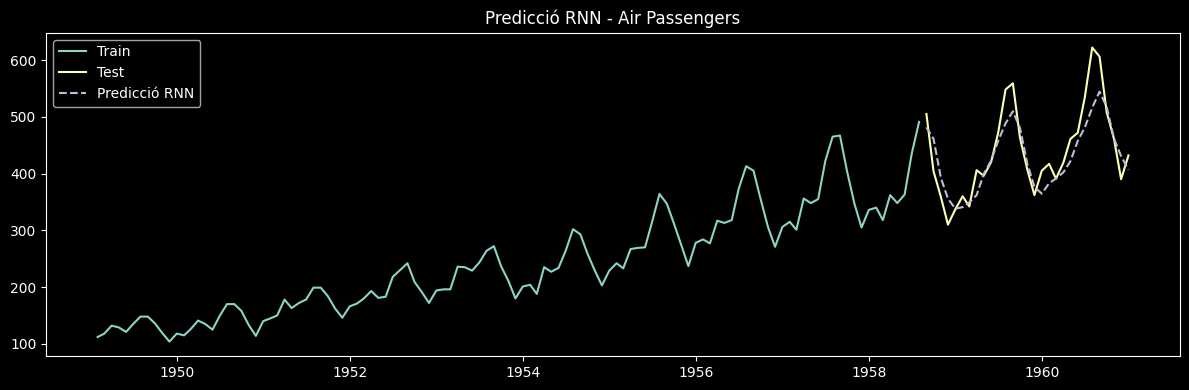

In [19]:
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test).numpy()

# Desnormalització
predictions = scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
y_test_real = scaler.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_test_real, predictions)
rmse = np.sqrt(np.mean((y_test_real - predictions) ** 2))
mape = np.mean(np.abs((y_test_real - predictions) / y_test_real)) * 100

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Visualització
test_index = data.index[train_size:]
plt.figure(figsize=(12, 4))
plt.plot(data.index[:train_size], series[:train_size], label='Train')
plt.plot(test_index, y_test_real, label='Test')
plt.plot(test_index, predictions, label='Predicció RNN', linestyle='--')
plt.legend()
plt.title('Predicció RNN - Air Passengers')
plt.tight_layout()
plt.show()

Tot i que la RNN millora respecte a l'ARIMA, segueix tenint dificultats per capturar l'estacionalitat a llarg termini a causa del problema del vanishing gradient. A la secció següent veurem com l'LSTM soluciona aquesta limitació.

## Exercici

https://surftemp.net/timeseries/index.html


Descarregueu una sèrie temporal de temperatura superficial del mar de la Mediterrània des de surftemp.net en format CSV. Trieu una zona geogràfica de la vostra elecció i resolució temporal mensual.
Un cop carregades les dades:

- Visualitzeu la sèrie i identifiqueu la tendència i l'estacionalitat.
- Prepareu les dades amb sliding window i divisió seqüencial train/test.
- Entreneu una RNN amb PyTorch per predir la SST del mes següent.
- Avalueu el model amb MAE, RMSE i MAPE i visualitzeu les prediccions.